# Training Rotational Branch

## Prepare training

### Import library

In [48]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from types import SimpleNamespace
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input


print("GPU:", tf.config.list_physical_devices("GPU"))
print("CPU:", tf.config.list_physical_devices("CPU"))

GPU: []
CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [49]:
%pwd

'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN'

In [50]:
CFG = SimpleNamespace(
    dataset_root="data-extraction/pseudo_dataset_08072026",

    image_subdir="img_left",
    mask_subdir="semantic",
    summary_csv="pseudo_ground_truth_summary.csv",

    image_size=(224, 224),   # H, W
    roi_size=(7, 7),         # ukuran hasil ROI Align pada feature map
    fc_dim = 128,
    
    batch_size=8,
    val_ratio=0.2,
    seed=42,

    bbox_margin=4,           # margin dalam ukuran 224x224
    min_mask_area=30,

    learning_rate=1e-4,
    epochs=50,

    save_model_path="rotation_branch_roi_align_vgg16.keras"
)

### utility file quternion

In [51]:
def natural_key(path):
    name = os.path.basename(str(path))
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", name)]


def list_files(folder, exts):
    folder = Path(folder)
    return sorted(
        [
            str(folder / f)
            for f in os.listdir(folder)
            if f.lower().endswith(exts)
        ],
        key=natural_key
    )


def normalize_quaternion_np(q, eps=1e-8):
    q = np.asarray(q, dtype=np.float32)
    norm = np.linalg.norm(q)

    if norm < eps:
        return q

    return q / norm

### load image, mask quaternion

In [52]:
def load_rotation_paths_and_labels(cfg):
    dataset_root = Path(cfg.dataset_root)

    image_dir = dataset_root / cfg.image_subdir
    mask_dir = dataset_root / cfg.mask_subdir
    summary_path = dataset_root / cfg.summary_csv

    image_paths = list_files(image_dir, (".jpg", ".jpeg", ".png", ".bmp"))
    mask_paths = list_files(mask_dir, (".jpg", ".jpeg", ".png", ".bmp"))

    df = pd.read_csv(summary_path)

    quat_cols = [
        "qw",
        "qx",
        "qy",
        "qz"
    ]

    for col in quat_cols:
        if col not in df.columns:
            raise ValueError(f"Kolom {col} tidak ditemukan di {summary_path}")

    quaternions = df[quat_cols].values.astype(np.float32)
    quaternions = np.array(
        [normalize_quaternion_np(q) for q in quaternions],
        dtype=np.float32
    )

    n = min(len(image_paths), len(mask_paths), len(quaternions))

    image_paths = np.array(image_paths[:n])
    mask_paths = np.array(mask_paths[:n])
    quaternions = quaternions[:n]

    print("Images     :", len(image_paths))
    print("Masks      :", len(mask_paths))
    print("Quaternions:", len(quaternions))
    print("Used       :", n)

    return image_paths, mask_paths, quaternions, df.iloc[:n].copy()

In [53]:
image_paths, mask_paths, quaternions, df_used = load_rotation_paths_and_labels(CFG)

print('Samples: ')
print(f"image       : {image_paths[0]}")
print(f"mask        : {mask_paths[0]}")
print(f"quaternion  : {quaternions[0]}")

Images     : 5972
Masks      : 5972
Quaternions: 5972
Used       : 5972
Samples: 
image       : data-extraction/pseudo_dataset_08072026/img_left/amik-vid-1-S-hand-img_2026-07-06_173426__amik-vid-1-S-frame-0-2026-07-06_173426_left_rectified.png
mask        : data-extraction/pseudo_dataset_08072026/semantic/amik-vid-1-S-hand-img_2026-07-06_173426__amik-vid-1-S-frame-0-2026-07-06_173426_left_rectified_sam_mask.png
quaternion  : [ 0.46947485  0.692115   -0.5307776  -0.13727836]


### preprocessing image and ROI bbox mask

In [54]:
def get_bbox_from_mask_resized(mask, margin=8, min_area=30):
    """
    mask: HxW binary mask, sudah ukuran model 224x224
    return: normalized bbox [y1, x1, y2, x2]
    """
    ys, xs = np.where(mask > 0)

    H, W = mask.shape[:2]

    if len(xs) < min_area:
        # fallback: seluruh image
        return np.array([0.0, 0.0, 1.0, 1.0], dtype=np.float32)

    x1 = max(0, int(xs.min()) - margin)
    y1 = max(0, int(ys.min()) - margin)
    x2 = min(W - 1, int(xs.max()) + margin)
    y2 = min(H - 1, int(ys.max()) + margin)

    box = np.array(
        [
            y1 / float(H - 1),
            x1 / float(W - 1),
            y2 / float(H - 1),
            x2 / float(W - 1)
        ],
        dtype=np.float32
    )

    return box


def preprocess_full_image_and_roi_np(
    image_path,
    mask_path,
    image_size=(224, 224),
    bbox_margin=8,
    min_mask_area=30
):
    image_path = image_path.decode("utf-8") if isinstance(image_path, bytes) else str(image_path)
    mask_path = mask_path.decode("utf-8") if isinstance(mask_path, bytes) else str(mask_path)

    image_bgr = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if image_bgr is None:
        raise ValueError(f"Gagal membaca image: {image_path}")

    if mask is None:
        raise ValueError(f"Gagal membaca mask: {mask_path}")

    target_h, target_w = image_size

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_rgb = cv2.resize(
        image_rgb,
        (target_w, target_h),
        interpolation=cv2.INTER_LINEAR
    )

    mask_resized = cv2.resize(
        mask,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST
    )

    mask_bin = (mask_resized > 127).astype(np.uint8)

    roi_box = get_bbox_from_mask_resized(
        mask_bin,
        margin=bbox_margin,
        min_area=min_mask_area
    )

    image_vgg = preprocess_input(image_rgb.astype(np.float32))

    return image_vgg.astype(np.float32), roi_box.astype(np.float32), mask_bin.astype(np.float32)

### Tensorflow dataloader

In [55]:
def tf_load_rotation_roi_sample(image_path, mask_path, quaternion, cfg):
    image, roi_box, mask_bin = tf.py_function(
        func=lambda img_p, msk_p: preprocess_full_image_and_roi_np(
            img_p.numpy(),
            msk_p.numpy(),
            image_size=cfg.image_size,
            bbox_margin=cfg.bbox_margin,
            min_mask_area=cfg.min_mask_area
        ),
        inp=[image_path, mask_path],
        Tout=[tf.float32, tf.float32, tf.float32]
    )

    image.set_shape([cfg.image_size[0], cfg.image_size[1], 3])
    roi_box.set_shape([4])
    mask_bin.set_shape([cfg.image_size[0], cfg.image_size[1]])

    quaternion = tf.cast(quaternion, tf.float32)
    quaternion = tf.math.l2_normalize(quaternion, axis=-1)

    inputs = {
        "image": image,
        "roi_box": roi_box
    }

    return inputs, quaternion


def make_rotation_roi_dataloader(
    image_paths,
    mask_paths,
    quaternions,
    cfg
):
    train_img, val_img, train_mask, val_mask, train_q, val_q = train_test_split(
        image_paths,
        mask_paths,
        quaternions,
        test_size=cfg.val_ratio,
        random_state=cfg.seed,
        shuffle=True
    )

    train_ds = tf.data.Dataset.from_tensor_slices(
        (train_img, train_mask, train_q)
    )

    val_ds = tf.data.Dataset.from_tensor_slices(
        (val_img, val_mask, val_q)
    )

    train_ds = train_ds.shuffle(
        buffer_size=len(train_img),
        seed=cfg.seed
    )

    train_ds = train_ds.map(
        lambda img, msk, q: tf_load_rotation_roi_sample(img, msk, q, cfg),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    val_ds = val_ds.map(
        lambda img, msk, q: tf_load_rotation_roi_sample(img, msk, q, cfg),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    train_ds = train_ds.batch(cfg.batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(cfg.batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds

In [56]:
train_rot_roi_ds, val_rot_roi_ds = make_rotation_roi_dataloader(
    image_paths=image_paths,
    mask_paths=mask_paths,
    quaternions=quaternions,
    cfg=CFG
)

for batch_inputs, batch_q in train_rot_roi_ds.take(1):
    print(batch_inputs["image"].shape)
    print(batch_inputs["roi_box"].shape)
    print(batch_q.shape)
    print(batch_inputs["roi_box"][0])
    print(batch_q[0])

(8, 224, 224, 3)
(8, 4)
(8, 4)
tf.Tensor([0.09865471 0.30493274 0.5515695  0.6547085 ], shape=(4,), dtype=float32)
tf.Tensor([-0.40577385  0.5651289  -0.55423415  0.45694792], shape=(4,), dtype=float32)


### visualisasi ROI bbox

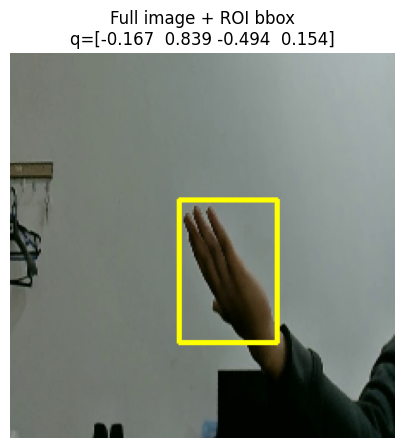

In [57]:
def reverse_vgg_preprocess(x):
    x = x.copy()

    x[..., 0] += 103.939
    x[..., 1] += 116.779
    x[..., 2] += 123.68

    x = x[..., ::-1]
    x = np.clip(x, 0, 255).astype(np.uint8)

    return x


def draw_normalized_bbox(image_rgb, box, color=(255, 255, 0)):
    """
    box format: [y1, x1, y2, x2], normalized
    """
    img = image_rgb.copy()
    H, W = img.shape[:2]

    y1, x1, y2, x2 = box

    x1 = int(round(x1 * (W - 1)))
    x2 = int(round(x2 * (W - 1)))
    y1 = int(round(y1 * (H - 1)))
    y2 = int(round(y2 * (H - 1)))

    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        color,
        2
    )

    return img


for batch_inputs, batch_q in train_rot_roi_ds.take(1):
    img_vgg = batch_inputs["image"][0].numpy()
    box = batch_inputs["roi_box"][0].numpy()

    img_rgb = reverse_vgg_preprocess(img_vgg)
    img_box = draw_normalized_bbox(img_rgb, box)

    plt.figure(figsize=(5, 5))
    plt.imshow(img_box)
    plt.title(f"Full image + ROI bbox\nq={np.round(batch_q[0].numpy(), 3)}")
    plt.axis("off")
    plt.show()

### quaternion loss and metric

In [58]:
def safe_l2_normalize(x, axis=-1, eps=1e-6):
    square_sum = tf.reduce_sum(tf.square(x), axis=axis, keepdims=True)
    denom = tf.sqrt(tf.maximum(square_sum, eps))
    return x / denom


@tf.keras.utils.register_keras_serializable(package="PoseCNN")
def quaternion_cosine_loss(y_true, y_pred):
    y_true = safe_l2_normalize(y_true, axis=-1)
    y_pred = safe_l2_normalize(y_pred, axis=-1)

    dot = tf.reduce_sum(y_true * y_pred, axis=-1)
    dot = tf.clip_by_value(tf.abs(dot), 0.0, 1.0)

    return tf.reduce_mean(1.0 - dot)


@tf.keras.utils.register_keras_serializable(package="PoseCNN")
def quaternion_angle_error_deg(y_true, y_pred):
    y_true = safe_l2_normalize(y_true, axis=-1)
    y_pred = safe_l2_normalize(y_pred, axis=-1)

    dot = tf.reduce_sum(y_true * y_pred, axis=-1)
    dot = tf.clip_by_value(tf.abs(dot), 0.0, 1.0)

    angle_rad = 2.0 * tf.acos(dot)
    angle_deg = angle_rad * 180.0 / np.pi

    return tf.reduce_mean(angle_deg)

## Arsitektur

### additional ROI align layer 

In [59]:
@tf.keras.utils.register_keras_serializable(package="PoseCNN")
class RoiAlignLayer(layers.Layer):
    def __init__(self, crop_size=(7, 7), eps=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.crop_size = tuple(crop_size)
        self.eps = eps

    def call(self, inputs):
        feature_map, boxes = inputs

        boxes = tf.cast(boxes, tf.float32)

        # Pastikan shape [batch, 4]
        boxes = tf.reshape(boxes, [-1, 4])

        # Replace NaN / inf dengan full image box
        default_boxes = tf.ones_like(boxes) * tf.constant(
            [0.0, 0.0, 1.0, 1.0],
            dtype=tf.float32
        )

        boxes = tf.where(
            tf.math.is_finite(boxes),
            boxes,
            default_boxes
        )

        y1, x1, y2, x2 = tf.split(boxes, 4, axis=-1)

        # Pastikan urutan benar
        ya = tf.minimum(y1, y2)
        yb = tf.maximum(y1, y2)
        xa = tf.minimum(x1, x2)
        xb = tf.maximum(x1, x2)

        # Clip ke range 0-1
        ya = tf.clip_by_value(ya, 0.0, 1.0 - self.eps)
        xa = tf.clip_by_value(xa, 0.0, 1.0 - self.eps)
        yb = tf.clip_by_value(yb, self.eps, 1.0)
        xb = tf.clip_by_value(xb, self.eps, 1.0)

        # Pastikan bbox tidak collapse
        yb = tf.maximum(yb, ya + self.eps)
        xb = tf.maximum(xb, xa + self.eps)

        yb = tf.clip_by_value(yb, 0.0, 1.0)
        xb = tf.clip_by_value(xb, 0.0, 1.0)

        safe_boxes = tf.concat([ya, xa, yb, xb], axis=-1)

        num_boxes = tf.shape(safe_boxes)[0]
        box_indices = tf.range(num_boxes, dtype=tf.int32)

        roi_features = tf.image.crop_and_resize(
            image=feature_map,
            boxes=safe_boxes,
            box_indices=box_indices,
            crop_size=self.crop_size,
            method="bilinear"
        )

        return roi_features

    def get_config(self):
        config = super().get_config()
        config.update({
            "crop_size": self.crop_size,
            "eps": self.eps
        })
        return config

In [60]:
for batch_inputs, batch_q in train_rot_roi_ds.take(1):
    boxes = batch_inputs["roi_box"]

    print("box shape:", boxes.shape)
    print("box min  :", tf.reduce_min(boxes).numpy())
    print("box max  :", tf.reduce_max(boxes).numpy())
    print("box NaN  :", tf.reduce_any(tf.math.is_nan(boxes)).numpy())
    print("box Inf  :", tf.reduce_any(tf.math.is_inf(boxes)).numpy())
    print("first box:", boxes[0].numpy())

box shape: (8, 4)
box min  : 0.13452914
box max  : 0.88340807
box NaN  : False
box Inf  : False
first box: [0.20179372 0.41704035 0.88340807 0.66367716]


### arsitektur branch rotation

In [61]:
def create_posecnn_style_rotation_branch(
    image_shape=(224, 224, 3),
    roi_size=(7, 7),
    train_encoder=False,
    fc_dim=4096,
    dropout_rate=0.5
):
    image_input = layers.Input(shape=image_shape, name="image")

    roi_box_input = layers.Input(shape=(4,), name="roi_box")

    encoder = VGG16(weights="imagenet", include_top=False, input_tensor=image_input)
    for layer in encoder.layers:
        layer.trainable = train_encoder

    # Extract specific layers to match the diagram
    block4_conv3 = encoder.get_layer('block4_conv3').output
    block5_conv3 = encoder.get_layer('block5_conv3').output

    feature_map = encoder.get_layer("block4_conv3").output
    roi_feature1 = RoiAlignLayer(crop_size=roi_size, name="roi_align_2")([feature_map, roi_box_input])

    # x = layers.Dropout(0.5)(x)

    x = layers.Flatten(name="roi_flatten")(roi_feature1)

    x = layers.Dense(fc_dim, activation="linear", name="fc_rotation_1")(x)
    x = layers.Dropout(dropout_rate)(x)

    # x = layers.Dense(fc_dim, activation="relu", name="fc_rotation_2")(x)
    # x = layers.Dropout(dropout_rate)(x)

    q_raw = layers.Dense(
        4,
        activation="linear",
        kernel_initializer=tf.keras.initializers.RandomNormal(stddev=1e-3),
        bias_initializer=tf.keras.initializers.Constant([1.0, 0.0, 0.0, 0.0]),
        name="rotation_quaternion_raw"
    )(x)

    # q_tanh = layers.Activation("tanh", name="poses_tanh")(q_raw)

    # q_norm = layers.Lambda(
    #     lambda t: safe_l2_normalize(t, axis=-1, eps=1e-6),
    #     name="rotation_quaternion"
    # )(q_tanh)

    model = Model(
        inputs={
            "image": image_input,
            "roi_box": roi_box_input
        },
        outputs=q_raw,
        name="PoseCNN_Style_Rotation_Branch"
    )

    return model

In [62]:
rotation_roi_model = create_posecnn_style_rotation_branch(
    image_shape=(CFG.image_size[0], CFG.image_size[1], 3),
    roi_size=CFG.roi_size,
    train_encoder=False,
    fc_dim=CFG.fc_dim,
    dropout_rate=0.5
)

rotation_roi_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CFG.learning_rate,
        clipnorm=1.0
    ),
    loss=quaternion_cosine_loss,
    metrics=[quaternion_angle_error_deg]
)

rotation_roi_model.summary()

Model: "PoseCNN_Style_Rotation_Branch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ image[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_box             │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_align_2         │ (None, 7, 7, 512) │          0 │ block4_conv3[0][… │
│ (RoiAlignLayer)     │                   │            │ roi_box[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_flatten         │ (None, 25088)     │          0 │ roi_align_2[0][0

 Total params: 10,847,172 (41.38 MB)

 Trainable params: 3,211,908 (12.25 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

### training

In [64]:
callbacks = [
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.ModelCheckpoint(
        CFG.save_model_path,
        monitor="val_quaternion_angle_error_deg",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_quaternion_angle_error_deg",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_quaternion_angle_error_deg",
        mode="min",
        patience=12,
        restore_best_weights=True,
        verbose=1
    )
]

In [65]:
history = rotation_roi_model.fit(
    train_rot_roi_ds,
    validation_data=val_rot_roi_ds,
    epochs=1,
    callbacks=callbacks
)

W0000 00:00:1783820577.211738   67483 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: -4 } dim { size: 28 } dim { size: 28 } dim { size: 512 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } value { dtype: DT_INT32 tensor_shape { dim { size: 2 } } int_val: 7 } } device { type: "CPU" vendor: "AuthenticAMD" model: "240" frequency: 3194 num_cores: 16 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 32768 l2_cache_size: 524288 l3_cache_size: 16777216 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size:

 15/598 ━━━━━━━━━━━━━━━━━━━━ 6:46 698ms/step - loss: 0.3603 - quaternion_angle_error_deg: 91.4776Batch 15: Invalid loss, terminating training
 16/598 ━━━━━━━━━━━━━━━━━━━━ 6:45 697ms/step - loss: nan - quaternion_angle_error_deg: nan       

W0000 00:00:1783820588.879276   67483 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: -4 } dim { size: 28 } dim { size: 28 } dim { size: 512 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } value { dtype: DT_INT32 tensor_shape { dim { size: 2 } } int_val: 7 } } device { type: "CPU" vendor: "AuthenticAMD" model: "240" frequency: 3194 num_cores: 16 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 32768 l2_cache_size: 524288 l3_cache_size: 16777216 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size:

KeyboardInterrupt: 

### plot training curve

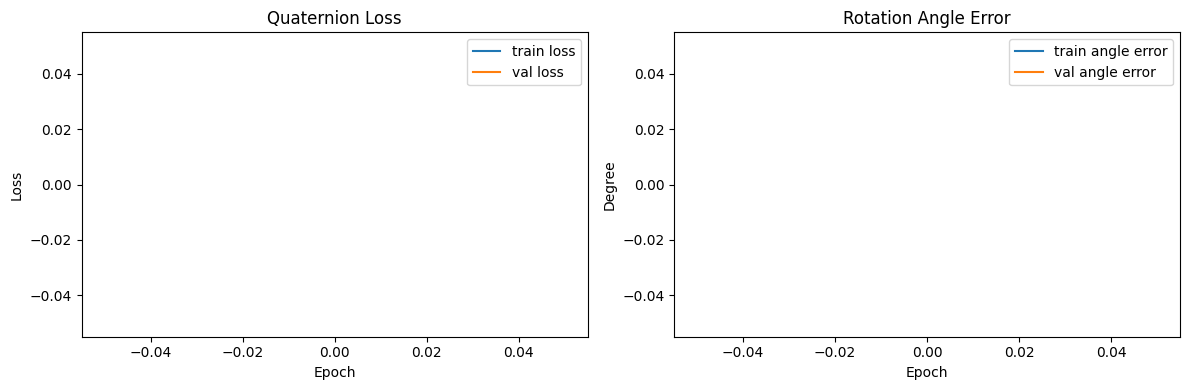

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Quaternion Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["quaternion_angle_error_deg"], label="train angle error")
plt.plot(history.history["val_quaternion_angle_error_deg"], label="val angle error")
plt.title("Rotation Angle Error")
plt.xlabel("Epoch")
plt.ylabel("Degree")
plt.legend()

plt.tight_layout()
plt.show()

### evaluation

In [ ]:
def predict_rotation_roi_samples(model, dataset, n=5):
    for batch_inputs, q_true_batch in dataset.take(1):
        q_pred_batch = model.predict(batch_inputs, verbose=0)

        for i in range(min(n, len(q_pred_batch))):
            img_vgg = batch_inputs["image"][i].numpy()
            box = batch_inputs["roi_box"][i].numpy()

            img_rgb = reverse_vgg_preprocess(img_vgg)
            img_box = draw_normalized_bbox(img_rgb, box)

            q_true = q_true_batch[i].numpy()
            q_pred = q_pred_batch[i]

            dot = np.abs(np.sum(q_true * q_pred))
            dot = np.clip(dot, 0.0, 1.0)

            angle = 2.0 * np.arccos(dot) * 180.0 / np.pi

            plt.figure(figsize=(5, 5))
            plt.imshow(img_box)
            plt.title(
                f"Angle error: {angle:.2f} deg\n"
                f"GT   : {np.round(q_true, 3)}\n"
                f"Pred : {np.round(q_pred, 3)}"
            )
            plt.axis("off")
            plt.show()

In [ ]:
predict_rotation_roi_samples(
    rotation_roi_model,
    val_rot_roi_ds,
    n=5
)